<a href="https://colab.research.google.com/github/RubennAlv/Probabilidad/blob/main/Unidad5/PracticaU5RegresionCorrelacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROBABILIDAD Y ESTADISTICA

##UNIDAD 2

###Facilitador: Jose Gabriel Rodrigues Rivas

### Alumno: Edwin Ruben Alvarado Mapula

##### **REGRESION LINEAL Y CORRELACION**



## Librerias

In [1]:
# importar las librerias que vamos a usar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression

print("librerias importadas")

librerias importadas


## Cargar archivos

In [2]:
# subir los csv desde la computadora
from google.colab import files
print("selecciona los 3 archivos csv")
uploaded = files.upload()

selecciona los 3 archivos csv


Saving grupo3.csv to grupo3.csv
Saving grupo2.csv to grupo2.csv
Saving grupo1.csv to grupo1.csv


In [3]:
# leer los archivos como dataframes
datos1 = pd.read_csv("grupo1.csv")
datos2 = pd.read_csv("grupo2.csv")
datos3 = pd.read_csv("grupo3.csv")

# ver como se ven los datos
print("grupo 1:")
print(datos1.head())
print()
print("grupo 2:")
print(datos2.head())
print()
print("grupo 3:")
print(datos3.head())

grupo 1:
   HorasEstudio  Calificacion
0         20.00         75.94
1         15.60         87.48
2         17.91         79.40
3         20.00         73.37
4         20.00         83.75

grupo 2:
   HorasEstudio  Calificacion
0          3.79          40.0
1          6.08          26.1
2          7.17          29.0
3          7.54          31.9
4          8.18          34.8

grupo 3:
   HorasEstudio  Calificacion
0          3.79          15.0
1          6.08          26.1
2          7.17          29.0
3          7.54          31.9
4          8.18          34.8


---
## Grupo 1

In [4]:
# descripcion estadistica del grupo 1
print("descripcion estadistica grupo 1")
print(datos1.describe())

descripcion estadistica grupo 1
       HorasEstudio  Calificacion
count     50.000000      50.00000
mean      14.352000      83.78820
std        4.219174       7.83389
min        3.790000      68.46000
25%       12.032500      78.03500
50%       14.600000      84.49000
75%       17.715000      88.09000
max       20.000000     100.00000


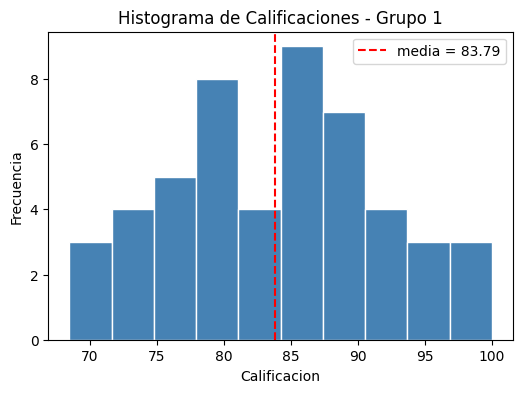

In [5]:
# histograma de calificaciones grupo 1
plt.figure(figsize=(6,4))
plt.hist(datos1["Calificacion"], bins=10, color="steelblue", edgecolor="white")
plt.title("Histograma de Calificaciones - Grupo 1")
plt.xlabel("Calificacion")
plt.ylabel("Frecuencia")
# linea de la media
media1 = datos1["Calificacion"].mean()
plt.axvline(media1, color="red", linestyle="--", label="media = " + str(round(media1, 2)))
plt.legend()
plt.show()

In [6]:
# preparar los datos para la regresion
x1 = datos1[["HorasEstudio"]].values
y1 = datos1["Calificacion"].values

# crear y entrenar el modelo
modelo1 = LinearRegression()
modelo1.fit(x1, y1)

# obtener pendiente e intercepto
pendiente1 = modelo1.coef_[0]
intercepto1 = modelo1.intercept_

print("ecuacion de regresion grupo 1:")
print("Calificacion =", round(intercepto1, 4), "+", round(pendiente1, 4), "* HorasEstudio")
print("pendiente:", round(pendiente1, 4))
print("intercepto:", round(intercepto1, 4))

ecuacion de regresion grupo 1:
Calificacion = 85.3107 + -0.1061 * HorasEstudio
pendiente: -0.1061
intercepto: 85.3107


In [7]:
# calcular correlacion de pearson grupo 1
r1, p1 = stats.pearsonr(datos1["HorasEstudio"], datos1["Calificacion"])
r2_1 = modelo1.score(x1, y1)

print("correlacion de pearson (r):", round(r1, 4))
print("valor p:", round(p1, 6))
print("coeficiente de determinacion (R2):", round(r2_1, 4))
print("el modelo explica el", round(r2_1*100, 1), "% de la variabilidad")

correlacion de pearson (r): -0.0571
valor p: 0.693509
coeficiente de determinacion (R2): 0.0033
el modelo explica el 0.3 % de la variabilidad


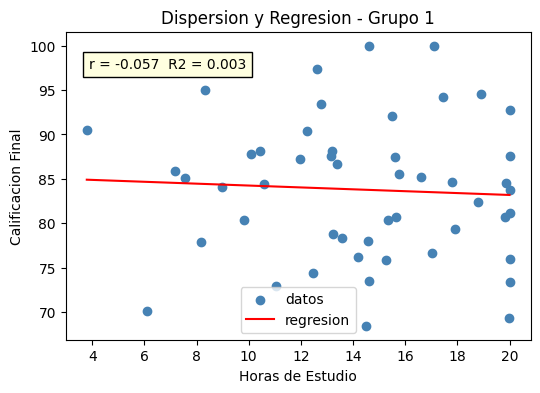

In [8]:
# grafica de dispersion con linea de regresion - grupo 1
plt.figure(figsize=(6,4))
plt.scatter(datos1["HorasEstudio"], datos1["Calificacion"], color="steelblue", label="datos")

# puntos para dibujar la linea
x_linea1 = np.linspace(datos1["HorasEstudio"].min(), datos1["HorasEstudio"].max(), 100)
y_linea1 = intercepto1 + pendiente1 * x_linea1
plt.plot(x_linea1, y_linea1, color="red", label="regresion")

plt.title("Dispersion y Regresion - Grupo 1")
plt.xlabel("Horas de Estudio")
plt.ylabel("Calificacion Final")
plt.legend()
# mostrar r y R2 en la grafica
plt.text(0.05, 0.88, "r = " + str(round(r1, 3)) + "  R2 = " + str(round(r2_1, 3)),
         transform=plt.gca().transAxes,
         bbox=dict(facecolor="lightyellow"))
plt.show()

In [9]:
# interpretacion grupo 1
print("=== Interpretacion Grupo 1 ===")
print()
print("1. Coeficiente de regresion (pendiente =", round(pendiente1, 4), "):")
print("   por cada hora mas de estudio, la calificacion cambia en promedio", round(pendiente1, 2), "puntos")
print()
print("2. Correlacion de Pearson (r =", round(r1, 4), "):")
if abs(r1) >= 0.7:
    print("   correlacion fuerte")
elif abs(r1) >= 0.5:
    print("   correlacion moderada")
else:
    print("   correlacion debil")
if r1 > 0:
    print("   direccion: positiva")
else:
    print("   direccion: negativa")
print()
print("3. Significancia estadistica:")
if p1 < 0.05:
    print("   si es significativo (p =", round(p1,4), "< 0.05)")
else:
    print("   no es significativo (p =", round(p1,4), "> 0.05)")
print()
print("4. Confiabilidad del modelo (R2 =", round(r2_1, 4), "):")
print("   el modelo explica el", round(r2_1*100, 1), "% de la variabilidad en las calificaciones")

=== Interpretacion Grupo 1 ===

1. Coeficiente de regresion (pendiente = -0.1061 ):
   por cada hora mas de estudio, la calificacion cambia en promedio -0.11 puntos

2. Correlacion de Pearson (r = -0.0571 ):
   correlacion debil
   direccion: negativa

3. Significancia estadistica:
   no es significativo (p = 0.6935 > 0.05)

4. Confiabilidad del modelo (R2 = 0.0033 ):
   el modelo explica el 0.3 % de la variabilidad en las calificaciones


---
## Grupo 2

In [10]:
print("descripcion estadistica grupo 2")
print(datos2.describe())

descripcion estadistica grupo 2
       HorasEstudio  Calificacion
count     50.000000     50.000000
mean      14.352000     75.912000
std        4.219174     20.668922
min        3.790000     26.100000
25%       12.032500     63.500000
50%       14.600000     78.550000
75%       17.715000     93.300000
max       20.000000     99.000000


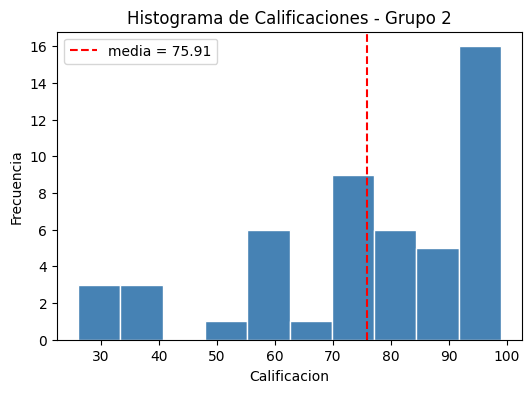

In [11]:
plt.figure(figsize=(6,4))
plt.hist(datos2["Calificacion"], bins=10, color="steelblue", edgecolor="white")
plt.title("Histograma de Calificaciones - Grupo 2")
plt.xlabel("Calificacion")
plt.ylabel("Frecuencia")
media2 = datos2["Calificacion"].mean()
plt.axvline(media2, color="red", linestyle="--", label="media = " + str(round(media2, 2)))
plt.legend()
plt.show()

In [14]:
x2 = datos2[["HorasEstudio"]].values
y2 = datos2["Calificacion"].values

modelo2 = LinearRegression()
modelo2.fit(x2, y2)

pendiente2 = modelo2.coef_[0]
intercepto2 = modelo2.intercept_

print("ecuacion de regresion grupo 2:")
print("Calificacion =", round(intercepto2, 4), "+", round(pendiente2, 4), "* HorasEstudio")
print("pendiente:", round(pendiente2, 4))
print("intercepto:", round(intercepto2, 4))

ecuacion de regresion grupo 2:
Calificacion = 15.3075 + 4.2227 * HorasEstudio
pendiente: 4.2227
intercepto: 15.3075


In [13]:
r2, p2 = stats.pearsonr(datos2["HorasEstudio"], datos2["Calificacion"])
r2_2 = modelo2.score(x2, y2)

print("correlacion de pearson (r):", round(r2, 4))
print("valor p:", round(p2, 6))
print("coeficiente de determinacion (R2):", round(r2_2, 4))
print("el modelo explica el", round(r2_2*100, 1), "% de la variabilidad")

correlacion de pearson (r): 0.862
valor p: 0.0
coeficiente de determinacion (R2): 0.743
el modelo explica el 74.3 % de la variabilidad


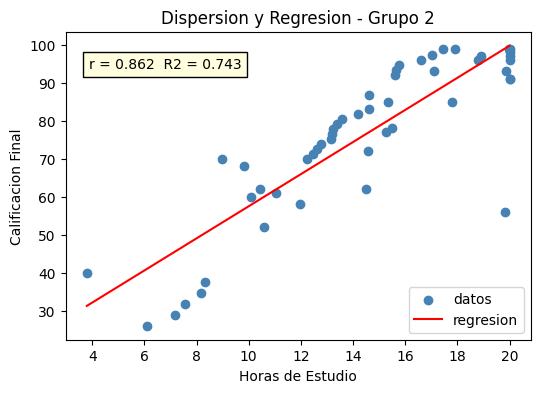

In [15]:
plt.figure(figsize=(6,4))
plt.scatter(datos2["HorasEstudio"], datos2["Calificacion"], color="steelblue", label="datos")

x_linea2 = np.linspace(datos2["HorasEstudio"].min(), datos2["HorasEstudio"].max(), 100)
y_linea2 = intercepto2 + pendiente2 * x_linea2
plt.plot(x_linea2, y_linea2, color="red", label="regresion")

plt.title("Dispersion y Regresion - Grupo 2")
plt.xlabel("Horas de Estudio")
plt.ylabel("Calificacion Final")
plt.legend()
plt.text(0.05, 0.88, "r = " + str(round(r2, 3)) + "  R2 = " + str(round(r2_2, 3)),
         transform=plt.gca().transAxes,
         bbox=dict(facecolor="lightyellow"))
plt.show()

In [16]:
print("=== Interpretacion Grupo 2 ===")
print()
print("1. Coeficiente de regresion (pendiente =", round(pendiente2, 4), "):")
print("   por cada hora mas de estudio, la calificacion cambia en promedio", round(pendiente2, 2), "puntos")
print()
print("2. Correlacion de Pearson (r =", round(r2, 4), "):")
if abs(r2) >= 0.7:
    print("   correlacion fuerte")
elif abs(r2) >= 0.5:
    print("   correlacion moderada")
else:
    print("   correlacion debil")
if r2 > 0:
    print("   direccion: positiva")
else:
    print("   direccion: negativa")
print()
print("3. Significancia estadistica:")
if p2 < 0.05:
    print("   si es significativo (p =", round(p2,4), "< 0.05)")
else:
    print("   no es significativo (p =", round(p2,4), "> 0.05)")
print()
print("4. Confiabilidad del modelo (R2 =", round(r2_2, 4), "):")
print("   el modelo explica el", round(r2_2*100, 1), "% de la variabilidad en las calificaciones")

=== Interpretacion Grupo 2 ===

1. Coeficiente de regresion (pendiente = 4.2227 ):
   por cada hora mas de estudio, la calificacion cambia en promedio 4.22 puntos

2. Correlacion de Pearson (r = 0.862 ):
   correlacion fuerte
   direccion: positiva

3. Significancia estadistica:
   si es significativo (p = 0.0 < 0.05)

4. Confiabilidad del modelo (R2 = 0.743 ):
   el modelo explica el 74.3 % de la variabilidad en las calificaciones


---
## Grupo 3

In [17]:
print("descripcion estadistica grupo 3")
print(datos3.describe())

descripcion estadistica grupo 3
       HorasEstudio  Calificacion
count     50.000000     50.000000
mean      14.352000     75.968000
std        4.219174     23.668867
min        3.790000     15.000000
25%       12.032500     61.000000
50%       14.600000     84.950000
75%       17.715000     94.375000
max       20.000000     99.000000


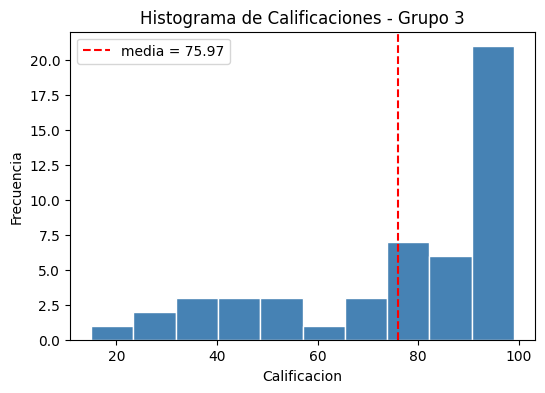

In [18]:
plt.figure(figsize=(6,4))
plt.hist(datos3["Calificacion"], bins=10, color="steelblue", edgecolor="white")
plt.title("Histograma de Calificaciones - Grupo 3")
plt.xlabel("Calificacion")
plt.ylabel("Frecuencia")
media3 = datos3["Calificacion"].mean()
plt.axvline(media3, color="red", linestyle="--", label="media = " + str(round(media3, 2)))
plt.legend()
plt.show()

In [19]:
x3 = datos3[["HorasEstudio"]].values
y3 = datos3["Calificacion"].values

modelo3 = LinearRegression()
modelo3.fit(x3, y3)

pendiente3 = modelo3.coef_[0]
intercepto3 = modelo3.intercept_

print("ecuacion de regresion grupo 3:")
print("Calificacion =", round(intercepto3, 4), "+", round(pendiente3, 4), "* HorasEstudio")
print("pendiente:", round(pendiente3, 4))
print("intercepto:", round(intercepto3, 4))

ecuacion de regresion grupo 3:
Calificacion = 0.1081 + 5.2857 * HorasEstudio
pendiente: 5.2857
intercepto: 0.1081


In [20]:
r3, p3 = stats.pearsonr(datos3["HorasEstudio"], datos3["Calificacion"])
r2_3 = modelo3.score(x3, y3)

print("correlacion de pearson (r):", round(r3, 4))
print("valor p:", round(p3, 6))
print("coeficiente de determinacion (R2):", round(r2_3, 4))
print("el modelo explica el", round(r2_3*100, 1), "% de la variabilidad")

correlacion de pearson (r): 0.9422
valor p: 0.0
coeficiente de determinacion (R2): 0.8878
el modelo explica el 88.8 % de la variabilidad


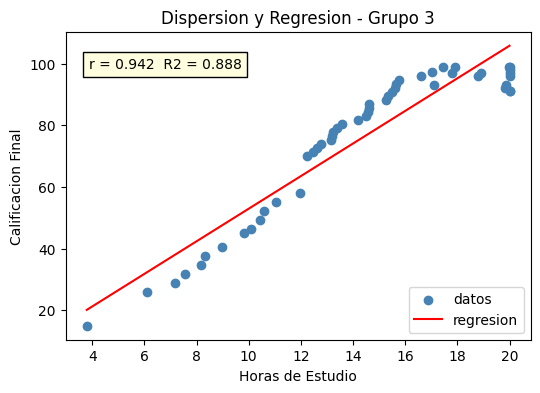

In [21]:
plt.figure(figsize=(6,4))
plt.scatter(datos3["HorasEstudio"], datos3["Calificacion"], color="steelblue", label="datos")

x_linea3 = np.linspace(datos3["HorasEstudio"].min(), datos3["HorasEstudio"].max(), 100)
y_linea3 = intercepto3 + pendiente3 * x_linea3
plt.plot(x_linea3, y_linea3, color="red", label="regresion")

plt.title("Dispersion y Regresion - Grupo 3")
plt.xlabel("Horas de Estudio")
plt.ylabel("Calificacion Final")
plt.legend()
plt.text(0.05, 0.88, "r = " + str(round(r3, 3)) + "  R2 = " + str(round(r2_3, 3)),
         transform=plt.gca().transAxes,
         bbox=dict(facecolor="lightyellow"))
plt.show()

In [22]:
print("=== Interpretacion Grupo 3 ===")
print()
print("1. Coeficiente de regresion (pendiente =", round(pendiente3, 4), "):")
print("   por cada hora mas de estudio, la calificacion cambia en promedio", round(pendiente3, 2), "puntos")
print()
print("2. Correlacion de Pearson (r =", round(r3, 4), "):")
if abs(r3) >= 0.7:
    print("   correlacion fuerte")
elif abs(r3) >= 0.5:
    print("   correlacion moderada")
else:
    print("   correlacion debil")
if r3 > 0:
    print("   direccion: positiva")
else:
    print("   direccion: negativa")
print()
print("3. Significancia estadistica:")
if p3 < 0.05:
    print("   si es significativo (p =", round(p3,4), "< 0.05)")
else:
    print("   no es significativo (p =", round(p3,4), "> 0.05)")
print()
print("4. Confiabilidad del modelo (R2 =", round(r2_3, 4), "):")
print("   el modelo explica el", round(r2_3*100, 1), "% de la variabilidad en las calificaciones")

=== Interpretacion Grupo 3 ===

1. Coeficiente de regresion (pendiente = 5.2857 ):
   por cada hora mas de estudio, la calificacion cambia en promedio 5.29 puntos

2. Correlacion de Pearson (r = 0.9422 ):
   correlacion fuerte
   direccion: positiva

3. Significancia estadistica:
   si es significativo (p = 0.0 < 0.05)

4. Confiabilidad del modelo (R2 = 0.8878 ):
   el modelo explica el 88.8 % de la variabilidad en las calificaciones


---
## Comparacion de los 3 grupos

In [23]:
# hacer una tabla con los resultados de los 3 grupos
resultados = {
    "Grupo":       ["Grupo 1", "Grupo 2", "Grupo 3"],
    "Pendiente":   [round(pendiente1,4), round(pendiente2,4), round(pendiente3,4)],
    "Intercepto":  [round(intercepto1,4), round(intercepto2,4), round(intercepto3,4)],
    "r Pearson":   [round(r1,4), round(r2,4), round(r3,4)],
    "p-valor":     [round(p1,6), round(p2,6), round(p3,6)],
    "R2":          [round(r2_1,4), round(r2_2,4), round(r2_3,4)]
}

tabla = pd.DataFrame(resultados)
tabla = tabla.set_index("Grupo")
print(tabla)

         Pendiente  Intercepto  r Pearson   p-valor      R2
Grupo                                                      
Grupo 1    -0.1061     85.3107    -0.0571  0.693509  0.0033
Grupo 2     4.2227     15.3075     0.8620  0.000000  0.7430
Grupo 3     5.2857      0.1081     0.9422  0.000000  0.8878


## Conclusiones generales

**Grupo 1:**
- r = -0.0571  → correlacion muy debil y negativa
- R2 = 0.0033  → el modelo solo explica el 0.3% de la variabilidad
- No es significativo (p = 0.69 > 0.05)
- Las horas de estudio practicamente no tienen relacion con la calificacion en este grupo

**Grupo 2:**
- r = 0.8620  → correlacion fuerte y positiva
- R2 = 0.7430 → el modelo explica el 74.3% de la variabilidad
- Si es significativo (p < 0.05)
- A mas horas de estudio, mayor calificacion. Por cada hora extra la calificacion sube ~4.2 puntos

**Grupo 3:**
- r = 0.9422  → correlacion muy fuerte y positiva
- R2 = 0.8878 → el modelo explica el 88.7% de la variabilidad
- Si es significativo (p < 0.05)
- Es el grupo con la relacion mas solida entre horas de estudio y calificaciones

En general, los resultados muestran que no todos los grupos
tienen la misma relacion entre horas de estudio y calificaciones.
El Grupo 3 tiene el modelo mas confiable, el Grupo 2 tambien
muestra una relacion significativa, pero el Grupo 1 sugiere que
otros factores influyen mas en el rendimiento de esos estudiantes.